# 01 bis — RASTER DENSITY PAR MODE (density_all)

Même pipeline que `03_RASTER_WALK_DENSITY` (section *density_all*), paramétrée par mode de transport.
Pas de profils utilisateurs : un seul GeoTIFF `density_all_<mode>.tif` en sortie.

**Pipeline**
1. Legs Grand Genève filtrés comme dans `01_DATAFRAME_CREATION` (`extreme99/98_length_mode = 0`, `usr_w_constant_bad_signal = 0`, départ **et** arrivée dans `agglo_GG`).
2. `n_days_GG` par user = jours avec ≥ 1 leg dans GG, **tous modes confondus** (même dénominateur que la marche).
3. Sélection des legs du mode choisi.
3b. OPTION : filtre horaire (`HOUR_START` / `HOUR_END`, sur l'heure locale de départ du leg) et filtre motif (`PURPOSES`). Non spécifiés → toutes heures / tous motifs.
4. Par user : rasterisation (10 m, `MergeAlg.add`) → ÷ `n_days_GG` → gaussien σ=1. Puis moyenne sur les users du mode.
5. CHOIX: Normalisation soit par sum(n_days) des usagers "mode_users" du mode considéré ou bien "all_users" pour tous les utilisateurs dans GG 
6. Clip agglo GG − Léman, export GeoTIFF EPSG:2056.

**Lancer pour un autre mode**
- à la main : changer `MODE` dans la cellule *PARAMÈTRES* ;
- en ligne de commande (papermill, la cellule est taguée `parameters`) :
  `papermill 04_RASTER_MODE_DENSITY.ipynb out_bike.ipynb -p MODE bike`
- avec filtres : `papermill ... -p MODE car -p HOUR_START 07:00 -p HOUR_END 09:00 -p PURPOSES '["Work"]'`
- ou variable d'environnement : `DENSITY_MODE=bike jupyter nbconvert --execute --to notebook 04_RASTER_MODE_DENSITY.ipynb`

# PARAMÈTRES

In [119]:
# ─── Paramètres (cellule taguée "parameters" pour papermill) ──────────────────
MODE          = "walk"       # "car" | "bike" | "walk" | clé de MODE_PRESETS, ou liste explicite ["Mode::X", ...]
SOURCE        = "parquet"   # "parquet" → réutilise legs_GG_all.parquet exporté par 01 (rapide, mêmes filtres)
                            # "gpkg"    → recalcule depuis 241120_legs.gpkg (si le parquet n'existe pas / pas à jour)
PIXEL_SIZE    = 10          # m
SIGMA         = 1           # lissage gaussien (en pixels)

# ─── Filtres à arbitrer (défauts = identiques à la pipeline marche) ───────────
MAX_SPEED_KMH = 15         # ex. 150 pour la voiture, 45 pour le vélo — None = pas de filtre (comme la marche)
DEDUP_LEG_ID  = True        # supprime les doublons de leg_id (le merge trip/journey de 01 peut dupliquer des legs)
NORMALIZE_BY  = "mode_users"  # "mode_users" → moyenne sur les users ayant ≥1 leg du mode (comme la marche)
                              # "all_users"  → moyenne sur tous les users GG (densité par habitant du panel, comparable entre modes)

# ─── Filtres horaire / motif (None = pas de filtre) ───────────────────────────
HOUR_START    = "04:00"        # "HH:MM" ou int (7 → "07:00"), heure locale de DÉPART du leg, borne incluse
HOUR_END      = "05:00"        # "HH:MM" ou int, borne EXCLUE ("24:00" accepté). Si START > END → passe minuit (ex. 22:00 → 06:00)
PURPOSES      = None        # None = tous les motifs | liste de valeurs de PURPOSE_COL, ex. ["Work", "Education"]
PURPOSE_COL   = "leading_stay_purpose"   # colonne motif dans legs_GG_all

RASTER_NAME   = None        # None → f"density_all_{MODE}[_HHMM-HHMM][_motif]"
OUTPUT_DIR    = "/Users/maximiliantrique/Documents/GitHub/projet_pieton_gg/Data/output/PL_output/density_walk_hourly"        # None → output_file_path_PL (même dossier que density_all.tif marche)

In [120]:
import os
import re

# Override possible par variable d'environnement
MODE       = os.environ.get("DENSITY_MODE",       MODE)
HOUR_START = os.environ.get("DENSITY_HOUR_START", HOUR_START)
HOUR_END   = os.environ.get("DENSITY_HOUR_END",   HOUR_END)
if os.environ.get("DENSITY_PURPOSES"):
    PURPOSES = [p.strip() for p in os.environ["DENSITY_PURPOSES"].split(",") if p.strip()]

# ─── Presets de modes ─────────────────────────────────────────────────────────
MODE_PRESETS = {
    "walk" : ["Mode::Walk"],
    "car"  : ["Mode::Car", "Mode::Ecar"],
    "bike" : ["Mode::Bicycle", "Mode::Ebicycle"],   # ← à arbitrer : + "Mode::KickScooter", "Mode::Ekickscooter" ?
}

if isinstance(MODE, (list, tuple)):
    MODE_LIST  = list(MODE)
    MODE_LABEL = "_".join(m.split("::")[-1].lower() for m in MODE_LIST)
else:
    if MODE not in MODE_PRESETS:
        raise ValueError(f"MODE inconnu : '{MODE}'. Presets : {list(MODE_PRESETS)} (ou passer une liste explicite)")
    MODE_LIST  = MODE_PRESETS[MODE]
    MODE_LABEL = MODE

# ─── Fenêtre horaire ──────────────────────────────────────────────────────────
def _to_minutes(t):
    """7 → 420 ; "07:30" → 450 ; "24:00" → 1440."""
    if isinstance(t, (int, float)):
        h, m = int(t), 0
    else:
        h, m = (list(map(int, str(t).strip().split(":"))) + [0])[:2]
    if not (0 <= h <= 24 and 0 <= m < 60) or h * 60 + m > 1440:
        raise ValueError(f"Heure invalide : {t!r}")
    return h * 60 + m

TIME_FILTER = (HOUR_START is not None) or (HOUR_END is not None)
if TIME_FILTER:
    T_START = _to_minutes(HOUR_START) if HOUR_START is not None else 0
    T_END   = _to_minutes(HOUR_END)   if HOUR_END   is not None else 1440
    if T_START == T_END:
        raise ValueError("HOUR_START == HOUR_END : fenêtre vide")
    TIME_LABEL = f"{T_START//60:02d}{T_START%60:02d}-{T_END//60:02d}{T_END%60:02d}"
else:
    T_START, T_END, TIME_LABEL = None, None, "all_day"

# ─── Motifs ───────────────────────────────────────────────────────────────────
if isinstance(PURPOSES, str):
    PURPOSES = [PURPOSES]
PURPOSE_FILTER = PURPOSES is not None and len(PURPOSES) > 0
PURPOSE_LABEL  = "+".join(re.sub(r"\W+", "", str(p).split("::")[-1]).lower() for p in PURPOSES) if PURPOSE_FILTER else "all"

# ─── Nom du raster ────────────────────────────────────────────────────────────
if RASTER_NAME is None:
    RASTER_NAME = f"density_all_{MODE_LABEL}"
    if TIME_FILTER:
        RASTER_NAME += f"_{TIME_LABEL}"
    if PURPOSE_FILTER:
        RASTER_NAME += f"_{PURPOSE_LABEL}"

print(f"MODE        : {MODE_LABEL} → {MODE_LIST}")
print(f"HORAIRE     : {TIME_LABEL}")
print(f"MOTIFS      : {PURPOSES if PURPOSE_FILTER else 'tous'}")
print(f"SOURCE      : {SOURCE}")
print(f"RASTER_NAME : {RASTER_NAME}")

MODE        : walk → ['Mode::Walk']
HORAIRE     : 0400-0500
MOTIFS      : tous
SOURCE      : parquet
RASTER_NAME : density_all_walk_0400-0500


# LIBRAIRIES

In [121]:
import sys
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import fiona
import rasterio
from affine import Affine
from rasterio.features import geometry_mask
from shapely.geometry import Point, LineString, MultiLineString
import warnings
warnings.filterwarnings("ignore")

sys.path.insert(0, os.path.abspath("../.."))
from utils.config import *
from utils.functions import *

if OUTPUT_DIR is None:
    OUTPUT_DIR = output_file_path_PL

# DONNÉES DE RÉFÉRENCE

In [122]:
agglo_GG  = gpd.read_file(f'{input_file_path}/network_agreg/AGGLO_PERIMETRE_AVEC_LAC-SHP/AGGLO_PERIMETRE_AVEC_LAC.shp').to_crs(epsg=2056)
lac_leman = gpd.read_file(input_file_path + "/network_agreg/LAC_LEMAN_WITHOUT_BRIDGE-SHP").to_crs(epsg=2056)

try:
    agglo_GG_geom = agglo_GG.union_all()
except AttributeError:
    agglo_GG_geom = agglo_GG.unary_union

# LEGS GG (tous modes)

On a besoin de **tous** les modes pour `n_days_GG` (dénominateur), puis on filtre le mode.

In [123]:
if SOURCE == "parquet":
    # ─── Route rapide : sortie de 01_DATAFRAME_CREATION (filtres qualité + intra_GG déjà appliqués) ─
    legs_GG_all = gpd.read_parquet(f'{output_file_path_PL}legs_GG_all.parquet')

    n_days_per_user = (
        legs_GG_all.groupby("user_id_fors")["n_days_GG"].first().to_dict()
    )

elif SOURCE == "gpkg":
    # ─── Route complète : même logique que 01 (cellule d7eee6e9) ──────────────
    def get_start_end_points(geom):
        if geom is None or geom.is_empty:
            return None, None
        if isinstance(geom, LineString):
            c = list(geom.coords)
            return Point(c[0]), Point(c[-1])
        if isinstance(geom, MultiLineString):
            parts = list(geom.geoms)
            return Point(list(parts[0].coords)[0]), Point(list(parts[-1].coords)[-1])
        return geom, geom

    def compute_intra_GG(gdf, perimeter_geom, perimeter_crs):
        gdf_proj = gdf.to_crs(perimeter_crs)
        starts, ends = zip(*gdf_proj.geometry.map(get_start_end_points))
        starts = gpd.GeoSeries(starts, crs=perimeter_crs)
        ends   = gpd.GeoSeries(ends,   crs=perimeter_crs)
        return (starts.intersects(perimeter_geom) & ends.intersects(perimeter_geom)).fillna(False).astype(int).values

    where_clause = """
        extreme99_length_mode = 0 AND
        extreme98_length_mode = 0 AND
        usr_w_constant_bad_signal = 0
    """
    keep_cols = ["leg_id", "user_id_fors", "mode", "length_leg", "duration",
                 "started_at_in_timezone", "legs_date", PURPOSE_COL, "geometry"]

    parts = []
    for layer in fiona.listlayers(f'{input_file_path_PL}241120_legs.gpkg'):
        g = gpd.read_file(f'{input_file_path_PL}241120_legs.gpkg', layer=layer, where=where_clause)
        if len(g) == 0:
            continue
        g = g[[c for c in keep_cols if c in g.columns]]
        g["intra_GG"] = compute_intra_GG(g, agglo_GG_geom, agglo_GG.crs)
        g = g[g["intra_GG"] == 1].copy()
        print(f"── {layer:<25} selected: {len(g):>6}")
        if len(g):
            parts.append(g)

    legs_GG_all = gpd.GeoDataFrame(pd.concat(parts, ignore_index=True), crs=parts[0].crs)
    del parts

    # legs_date : colonne brute si présente, sinon date locale de départ (comme 01, cellule dce84bb9)
    if "legs_date" not in legs_GG_all.columns:
        legs_GG_all["legs_date"] = (
            pd.to_datetime(legs_GG_all["started_at_in_timezone"], utc=True)
              .dt.tz_convert("Europe/Zurich").dt.date
        )

    n_days_per_user = legs_GG_all.groupby("user_id_fors")["legs_date"].nunique().to_dict()
    legs_GG_all["n_days_GG"] = legs_GG_all["user_id_fors"].map(n_days_per_user)

else:
    raise ValueError(f"SOURCE inconnue : {SOURCE}")

legs_GG_all = legs_GG_all.to_crs(epsg=2056)
N_USERS_ALL = legs_GG_all["user_id_fors"].nunique()

print(f"\nlegs_GG_all : {len(legs_GG_all):,} legs / {N_USERS_ALL} users")
print(f"n_days_GG   : médiane {np.median(list(n_days_per_user.values())):.0f} | "
      f"min {min(n_days_per_user.values())} | max {max(n_days_per_user.values())}")


legs_GG_all : 240,157 legs / 1997 users
n_days_GG   : médiane 18 | min 1 | max 43


In [124]:
# ─── Modes disponibles (vérifier les libellés exacts) ─────────────────────────
mode_counts = legs_GG_all["mode"].value_counts()
print(mode_counts.to_string())

missing = [m for m in MODE_LIST if m not in mode_counts.index]
if missing:
    print(f"\n⚠ Modes absents des données : {missing}")
if not any(m in mode_counts.index for m in MODE_LIST):
    raise ValueError(f"Aucun des modes {MODE_LIST} n'existe dans legs_GG_all['mode']")

mode
Mode::Walk             128613
Mode::Car               66931
Mode::Bus               12702
Mode::Bicycle           12300
Mode::Tram               5741
Mode::Motorbike          3060
Mode::Train              2857
Mode::Ecar               2776
Mode::Ebicycle           2773
Mode::RegionalTrain      1040
Mode::Other               420
Mode::LightRail           292
Mode::Carsharing          282
Mode::Boat                159
Mode::KickScooter         138
Mode::TaxiUber             63
Mode::Airplane              8
Mode::Bikesharing           1
Mode::Subway                1


# SÉLECTION DU MODE + FILTRES

In [125]:
gdf = legs_GG_all[legs_GG_all["mode"].isin(MODE_LIST) & legs_GG_all.geometry.notna()].copy()
print(f"Legs {MODE_LABEL} bruts       : {len(gdf):,} / {gdf['user_id_fors'].nunique()} users")

# ─── Doublons leg_id ──────────────────────────────────────────────────────────
n_dup = gdf["leg_id"].duplicated().sum()
print(f"Doublons leg_id          : {n_dup:,}")
if DEDUP_LEG_ID and n_dup:
    gdf = gdf.drop_duplicates(subset="leg_id").copy()
    print(f"  → supprimés, reste {len(gdf):,}")

# ─── Vitesse ──────────────────────────────────────────────────────────────────
gdf["speed_kmh"] = gdf["length_leg"] / (gdf["duration"] / 3600) / 1000
print("\nVitesse (km/h) :")
print(gdf["speed_kmh"].describe(percentiles=[.5, .9, .95, .99, .999]).round(1).to_string())

if MAX_SPEED_KMH is not None:
    n_fast = (gdf["speed_kmh"] > MAX_SPEED_KMH).sum()
    gdf = gdf[~(gdf["speed_kmh"] > MAX_SPEED_KMH)].copy()
    print(f"\nFiltre vitesse > {MAX_SPEED_KMH} km/h : {n_fast:,} legs retirés, reste {len(gdf):,}")

# ─── Référence users du mode (AVANT filtres horaire / motif) ─────────────────
# Sert de dénominateur "mode_users" : les rasters par créneau / motif restent
# additifs et comparables à density_all_<mode> (même population).
N_USERS_MODE = gdf["user_id_fors"].nunique()
print(f"\nUsers du mode (référence) : {N_USERS_MODE}")

# ─── Filtre horaire (heure locale de départ) ──────────────────────────────────
if TIME_FILTER:
    if "started_at_local" in gdf.columns:
        t_local = pd.to_datetime(gdf["started_at_local"], utc=True).dt.tz_convert("Europe/Zurich")
    else:
        t_local = pd.to_datetime(gdf["started_at_in_timezone"], utc=True).dt.tz_convert("Europe/Zurich")
    t_min = t_local.dt.hour * 60 + t_local.dt.minute

    if T_START < T_END:
        time_mask = (t_min >= T_START) & (t_min < T_END)
    else:                                   # fenêtre qui passe minuit
        time_mask = (t_min >= T_START) | (t_min < T_END)

    n_before = len(gdf)
    gdf = gdf[time_mask.values].copy()
    print(f"Filtre horaire {TIME_LABEL}   : {len(gdf):,} / {n_before:,} legs gardés")

# ─── Filtre motif ─────────────────────────────────────────────────────────────
if PURPOSE_COL in gdf.columns:
    print(f"\nMotifs disponibles ({PURPOSE_COL}) :")
    print(gdf[PURPOSE_COL].value_counts(dropna=False).to_string())
elif PURPOSE_FILTER:
    raise KeyError(f"Colonne motif '{PURPOSE_COL}' absente de legs_GG_all")

if PURPOSE_FILTER:
    unknown = [p for p in PURPOSES if p not in set(gdf[PURPOSE_COL].dropna().unique())]
    if unknown:
        print(f"⚠ Motifs absents (après filtres précédents) : {unknown}")
    n_before = len(gdf)
    gdf = gdf[gdf[PURPOSE_COL].isin(PURPOSES)].copy()
    print(f"Filtre motif {PURPOSES} : {len(gdf):,} / {n_before:,} legs gardés")

if len(gdf) == 0:
    raise ValueError("Aucun leg après filtres horaire / motif")

print(f"\nFeatures à rasteriser : {len(gdf):,}")
print(f"Users                 : {gdf['user_id_fors'].nunique()}")
print(f"Répartition modes     :\n{gdf['mode'].value_counts().to_string()}")

Legs walk bruts       : 128,613 / 1980 users
Doublons leg_id          : 0

Vitesse (km/h) :
count    128613.0
mean          5.2
std           6.4
min           0.0
50%           4.3
90%           8.6
95%          11.8
99%          25.2
99.9%        67.2
max         643.7

Filtre vitesse > 15 km/h : 4,263 legs retirés, reste 124,350

Users du mode (référence) : 1973
Filtre horaire 0400-0500   : 175 / 124,350 legs gardés

Motifs disponibles (leading_stay_purpose) :
leading_stay_purpose
home              49
work              34
wait              27
None              22
errand            17
leisure            8
unknown            5
eat                5
shopping           3
family_friends     2
other              2
study              1

Features à rasteriser : 175
Users                 : 90
Répartition modes     :
mode
Mode::Walk    175


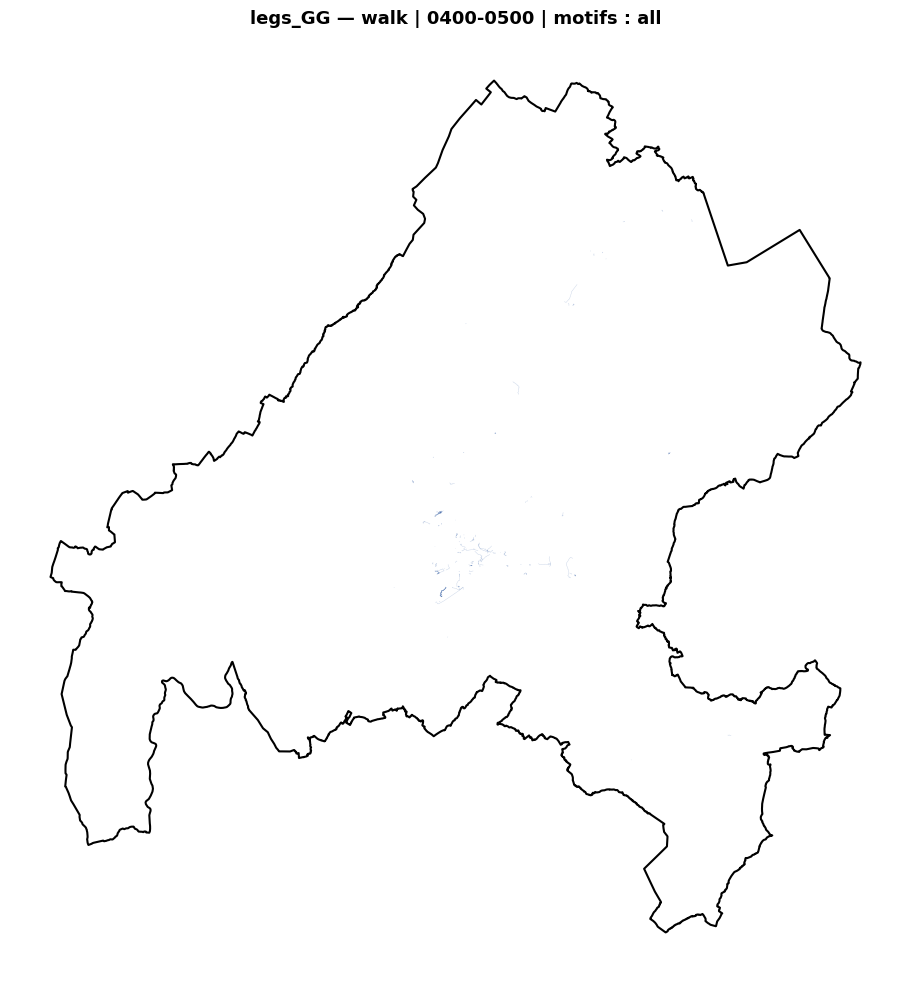

In [126]:
fig, ax = plt.subplots(figsize=(10, 10))
fig.suptitle(f"legs_GG — {MODE_LABEL} | {TIME_LABEL} | motifs : {PURPOSE_LABEL}", fontsize=13, fontweight="bold")
gdf.plot(ax=ax, color="#4C72B0", linewidth=0.3, alpha=0.3)
agglo_GG.boundary.plot(ax=ax, color="black", linewidth=1.5)
ax.set_axis_off()
plt.tight_layout()
plt.show()

# GRILLE + MASQUE (identiques à la marche)

In [127]:
xmin, ymin, xmax, ymax = agglo_GG.total_bounds
raster_width  = int((xmax - xmin) / PIXEL_SIZE)
raster_height = int((ymax - ymin) / PIXEL_SIZE)
transform     = Affine(PIXEL_SIZE, 0, xmin, 0, -PIXEL_SIZE, ymax)
extent        = [xmin, xmax, ymin, ymax]

canton_mask = geometry_mask(agglo_GG.geometry,  out_shape=(raster_height, raster_width), transform=transform, invert=True)
lac_mask    = geometry_mask(lac_leman.geometry, out_shape=(raster_height, raster_width), transform=transform, invert=True)
agglo_GG_mask = canton_mask & ~lac_mask

print(f"raster {raster_width} x {raster_height} | pixels agglo hors lac : {agglo_GG_mask.sum():,}")

raster 6553 x 6891 | pixels agglo hors lac : 19,885,278


# RASTER density_all

In [128]:
raster_density, meta = build_density_raster_v2(
    gdf_group       = gdf,
    raster_height   = raster_height,
    raster_width    = raster_width,
    transform       = transform,
    canton_mask     = agglo_GG_mask,
    n_days_per_user = n_days_per_user,
    sigma           = SIGMA,
    verbose         = False,
    output_path     = None,          # export géré plus bas (pour gérer NORMALIZE_BY)
    raster_name     = None,
)

# build_density_raster_v2 moyenne sur les users présents dans gdf (n_users_valid).
# Avec un filtre horaire / motif, ce sont seulement les users ayant ≥1 leg dans le filtre
# → on ramène la moyenne à la population de référence :
#   "mode_users" : users ayant ≥1 leg du mode (toutes heures / motifs)  → identique à avant sans filtre
#   "all_users"  : tous les users GG
if NORMALIZE_BY == "mode_users":
    N_REF = N_USERS_MODE
elif NORMALIZE_BY == "all_users":
    N_REF = N_USERS_ALL
else:
    raise ValueError(f"NORMALIZE_BY inconnu : {NORMALIZE_BY}")

raster_density = raster_density * meta["n_users_valid"] / N_REF

meta.update({"mode": MODE_LABEL, "modes": MODE_LIST, "normalize_by": NORMALIZE_BY,
             "n_users_ref": N_REF, "n_users_mode": N_USERS_MODE, "n_users_all": N_USERS_ALL,
             "max_speed_kmh": MAX_SPEED_KMH,
             "time_window": TIME_LABEL,
             "purposes": PURPOSES if PURPOSE_FILTER else "all", "purpose_col": PURPOSE_COL,
             "n_legs": len(gdf)})
print(meta)


  → 90 users valides / 90 total
  → 0 users skippés
  → pixels actifs : 48,449
  → raster max    : 0.008578
{'n_users_total': 90, 'n_users_valid': 90, 'n_users_skipped': 0, 'sigma': 1, 'pixels_actifs': 48449, 'raster_max': 0.008577849715948105, 'raster_min': 0.0, 'mode': 'walk', 'modes': ['Mode::Walk'], 'normalize_by': 'mode_users', 'n_users_ref': 1973, 'n_users_mode': 1973, 'n_users_all': 1997, 'max_speed_kmh': 15, 'time_window': '0400-0500', 'purposes': 'all', 'purpose_col': 'leading_stay_purpose', 'n_legs': 175}


In [129]:
# ─── Export GeoTIFF (même format que density_all.tif marche) ──────────────────
os.makedirs(OUTPUT_DIR, exist_ok=True)
filepath = os.path.join(OUTPUT_DIR, f"{RASTER_NAME}.tif")

with rasterio.open(
    filepath, mode="w", driver="GTiff",
    height=raster_height, width=raster_width, count=1,
    dtype="float32", crs="EPSG:2056", transform=transform, nodata=np.nan,
    compress="deflate",
) as dst:
    dst.write(raster_density.astype("float32"), 1)
    dst.update_tags(**{k: str(v) for k, v in meta.items()})

print(f"✓ exporté : {filepath}")

✓ exporté : /Users/maximiliantrique/Documents/GitHub/projet_pieton_gg/Data/output/PL_output/density_walk_hourly/density_all_walk_0400-0500.tif


# CONTRÔLE

EPSG:2056 (10.0, 10.0) (6891, 6553)
pixels actifs : 48,449
P50 : 0.000000
P75 : 0.000003
P90 : 0.000008
P95 : 0.000018
P99 : 0.000085
max  : 0.000391


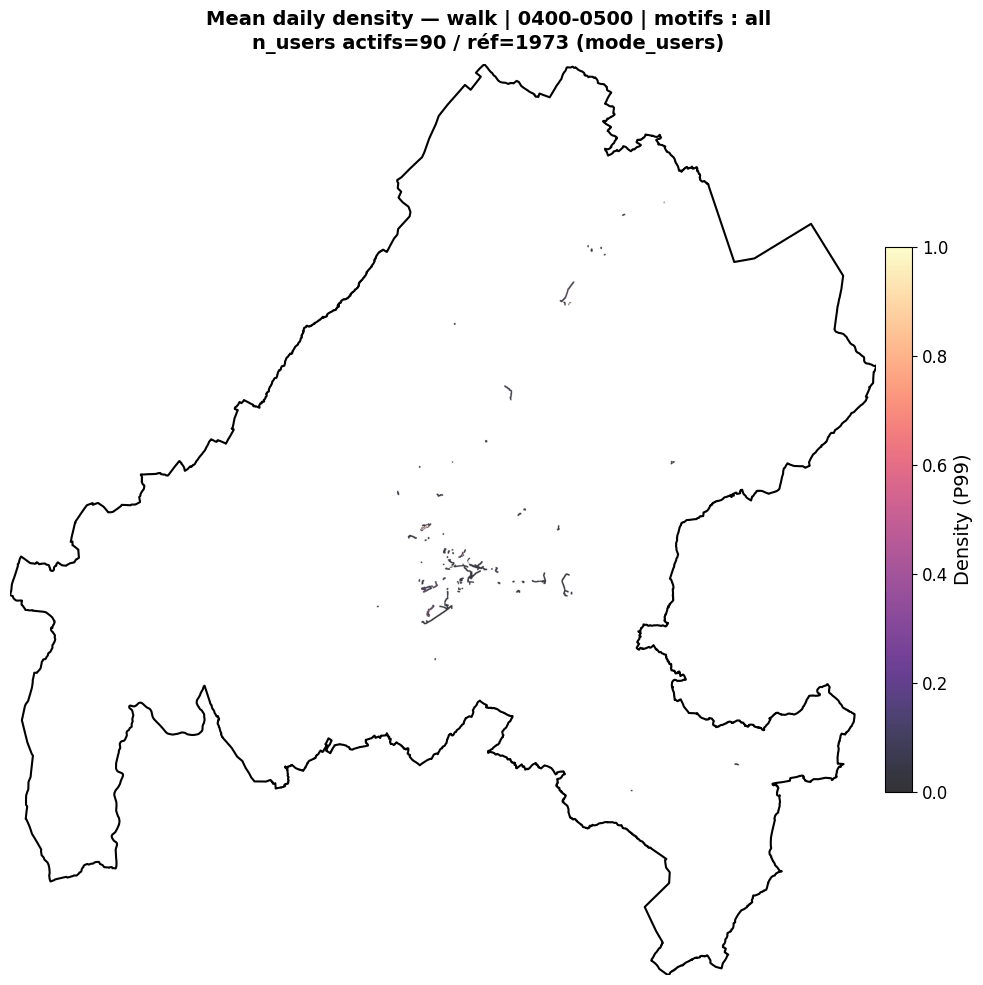

In [130]:
with rasterio.open(filepath) as src:
    r = src.read(1).astype("float32")
    print(src.crs, src.res, src.shape)

active = r[~np.isnan(r) & (r > 0)]
print(f"pixels actifs : {len(active):,}")
for p in [50, 75, 90, 95, 99]:
    print(f"P{p:<3}: {np.percentile(active, p):.6f}")
print(f"max  : {active.max():.6f}")

d_max  = compute_scale([r], clip_percentile, mode=norm_mode)
r_norm = normalize_raster(r, d_max, mode=norm_mode)
plot_density_map(
    r_norm,
    title=f"Mean daily density — {MODE_LABEL} | {TIME_LABEL} | motifs : {PURPOSE_LABEL}\nn_users actifs={meta['n_users_valid']} / réf={N_REF} ({NORMALIZE_BY})",
    extent=extent, canton_GE=agglo_GG, girec=None,
)